# ✅ Musterlösung: Hands-On Chronos

Vollständige Lösung zu `2_chronos_handson_students.ipynb`. Aufgabe 1, 2a und 2b ausgefüllt, mit kurzen Begründungen.

---
## 0 · Setup & Daten *(identisch zum Studenten-Notebook)*

In [1]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import BaseChronosPipeline
np.random.seed(0); torch.manual_seed(0)

def print_metrics(y_true, y_pred, label='Modell'):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label:<28} RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:5.1f}%')
    return {'label': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

def plot_forecast(y_train, y_true, median, lo, hi, label, n_context=90):
    H = len(y_true)
    xh = np.arange(-min(n_context, len(y_train)), 0); xf = np.arange(0, H)
    plt.figure(figsize=(13, 4))
    plt.plot(xh, y_train[-len(xh):], color='gray', label='Historie')
    plt.plot(xf, y_true, color='black', marker='.', label='Test (echt)')
    plt.plot(xf, median, color='C1', label=f'{label} - Median')
    plt.fill_between(xf, lo, hi, color='C1', alpha=0.25, label='10-90%-Band')
    plt.axvline(0, color='k', ls=':'); plt.legend(); plt.title(label)
    plt.tight_layout(); plt.show()

In [2]:
def make_skydrive(seed=7):
    rng = np.random.default_rng(seed)
    dates = pd.date_range('2022-01-01', '2023-12-31', freq='D')
    t = np.arange(len(dates))
    dow = np.asarray(dates.dayofweek)                      # als NumPy-Array statt pandas-Index
    base = 200 + 0.15 * t + 30 * np.sin(2 * np.pi * dow / 7)
    sales = np.asarray(base, dtype=float) + rng.normal(0, 12, len(dates))
    for yr in [2022, 2023]:
        fr = dates[(dates.year == yr) & (dates.month == 11) & (dates.dayofweek == 4)]
        bf = fr[3]
        for d, boost in [(bf - pd.Timedelta(days=1), 0.5), (bf, 2.5),
                         (bf + pd.Timedelta(days=1), 1.0), (bf + pd.Timedelta(days=3), 1.2)]:
            i = dates.get_indexer([d])[0]
            if i >= 0:
                sales[i] += base[i] * boost
    return pd.DataFrame({'ds': dates, 'y': np.clip(sales, 0, None)})

def black_friday_flag(dates):
    dates = pd.DatetimeIndex(dates)              # akzeptiert Series ODER Index
    flag = np.zeros(len(dates), float)
    for yr in np.unique(dates.year):
        fr = dates[(dates.year == yr) & (dates.month == 11) & (dates.dayofweek == 4)]
        if len(fr) >= 4:
            win = pd.date_range(fr[3] - pd.Timedelta(days=1), fr[3] + pd.Timedelta(days=3))
            flag[dates.isin(win)] = 1.0
    return flag

df = make_skydrive()
df['black_friday'] = black_friday_flag(df['ds'])
H = 49
y = df['y'].to_numpy(float)
y_train, y_test = y[:-H], y[-H:]

---
## ✅ Lösung Aufgabe 1 – Naiver Zero-Shot-Forecast

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Aufgabe 1: naiv              RMSE=   124.0  MAE=    40.5  MAPE=  7.4%


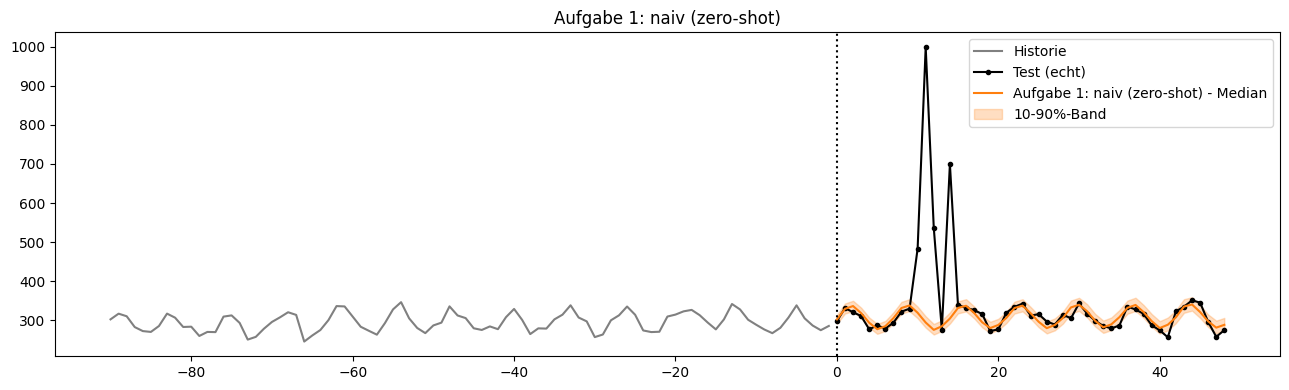

In [3]:
pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

# erstes Argument heißt 'inputs' (aktuelle Chronos-Version)
quantiles, mean = pipe.predict_quantiles(
    inputs=torch.tensor(y_train, dtype=torch.float32),
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
)
lo1     = quantiles[0, :, 0].numpy()
median1 = quantiles[0, :, 1].numpy()
hi1     = quantiles[0, :, 2].numpy()

m1 = print_metrics(y_test, median1, 'Aufgabe 1: naiv')
plot_forecast(y_train, y_test, median1, lo1, hi1, 'Aufgabe 1: naiv (zero-shot)')

**Kommentar:** Chronos ist zero-shot – die Punktprognose ist der Median (`quantiles[0,:,1]`), das Band kommt aus den Quantilen 0.1/0.9. Das naive Modell kennt den Kalender nicht und **verpasst den Black-Friday-Peak** im Test (die rote Spitze wird nicht getroffen).

---
## ✅ Lösung Aufgabe 2a – größeres Modell (`bolt-base`)

In [4]:
pipe_b = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-base', device_map='cpu')
q, _ = pipe_b.predict_quantiles(
    inputs=torch.tensor(y_train, dtype=torch.float32),
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
)
median_2a = q[0, :, 1].numpy()
m2a = print_metrics(y_test, median_2a, 'Aufgabe 2a: bolt-base')

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

Aufgabe 2a: bolt-base        RMSE=   123.5  MAE=    40.3  MAPE=  7.4%


---
## ✅ Lösung Aufgabe 2b – Black Friday als Kovariate (Chronos-2)

Das ist das **Experten-Modell**: Wir geben dem Modell die bekannte Information „an diesen Tagen ist Black Friday" mit – auch für die Zukunft (`future_df`).

In [5]:
from chronos import Chronos2Pipeline

pipe2 = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')

context_df = pd.DataFrame({
    'id': 'skydrive',
    'timestamp': df['ds'][:-H].values,
    'target': y_train,
    'black_friday': df['black_friday'].to_numpy()[:-H],
})
future_df = pd.DataFrame({
    'id': 'skydrive',
    'timestamp': df['ds'][-H:].values,
    'black_friday': df['black_friday'].to_numpy()[-H:],
})

pred_df = pipe2.predict_df(
    context_df, future_df=future_df, prediction_length=H,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column='id', timestamp_column='timestamp', target='target',
)
median_2b = pred_df['0.5'].to_numpy()
m2b = print_metrics(y_test, median_2b, 'Aufgabe 2b: Chronos-2 + Black Friday')

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Aufgabe 2b: Chronos-2 + Black Friday RMSE=    67.3  MAE=    26.8  MAPE=  6.2%


---
## 📊 Showdown & Fazit

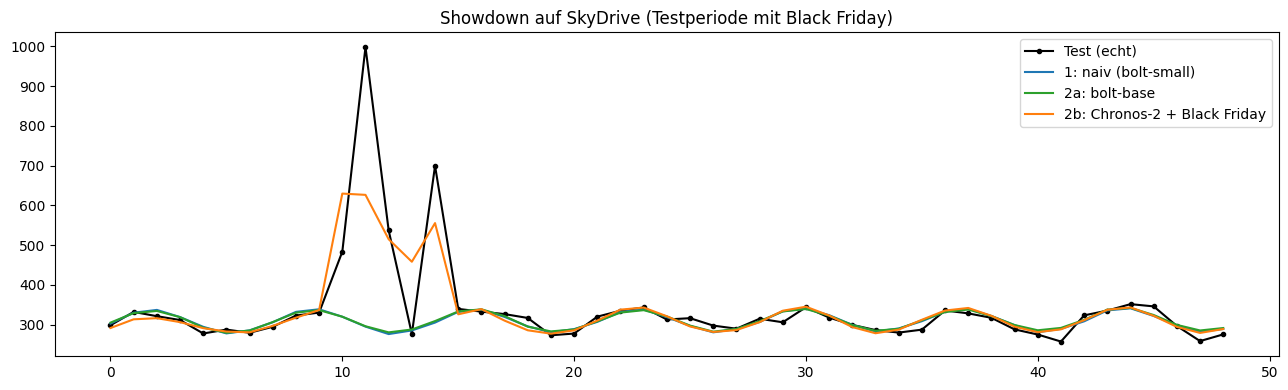

,RMSE,MAE,MAPE
label,,,
Aufgabe 1: naiv,124.0,40.5,7.4
Aufgabe 2a: bolt-base,123.5,40.3,7.4
Aufgabe 2b: Chronos-2 + Black Friday,67.3,26.8,6.2


In [6]:
xf = np.arange(H)
plt.figure(figsize=(13, 4))
plt.plot(xf, y_test, color='black', marker='.', label='Test (echt)')
plt.plot(xf, median1,   color='C0', label='1: naiv (bolt-small)')
plt.plot(xf, median_2a, color='C2', label='2a: bolt-base')
plt.plot(xf, median_2b, color='C1', label='2b: Chronos-2 + Black Friday')
plt.title('Showdown auf SkyDrive (Testperiode mit Black Friday)')
plt.legend(); plt.tight_layout(); plt.show()

pd.DataFrame([m1, m2a, m2b]).set_index('label').round(1)

**Kommentar:** Das größere Modell (2a) hilft meist nur leicht – es kennt den Black Friday weiterhin nicht. Erst die **Kovariate** (2b) sagt dem Modell explizit, *wann* der Peak kommt, und senkt den Fehler im Black-Friday-Fenster deutlich. Das ist das direkte Chronos-Gegenstück zu Prophets „Experten-Modell mit Black Friday".

---
## 💬 Antworten zu den Diskussionsfragen

**1. Warum funktioniert Chronos ohne `fit()` und ohne Feiertage?**
Chronos ist auf sehr vielen Zeitreihen **vortrainiert** und hat typische Muster (Trend, Wochen-/Jahressaison) bereits gelernt. Es überträgt dieses Wissen *zero-shot* auf neue Reihen – ähnlich wie ein Sprachmodell Texte vervollständigt, ohne für jeden Text neu trainiert zu werden.

**2. Was bringt am meisten?**
Mehr Kontext und ein größeres Modell helfen bei den „normalen" Mustern. Den **einmaligen** Black-Friday-Peak trifft aber nur die **Kovariate**, weil das Modell den Kalender sonst nicht kennt.

**3. Prophet oder Chronos?**
- **Prophet:** wenn Erklärbarkeit zählt, Domänenwissen (Feiertage, Aktionen) klar einbaubar ist, wenig Rechenleistung da ist.
- **Chronos:** wenn schnell ein starker Forecast ohne Feature-Engineering gebraucht wird, viele Reihen parallel zu prognostizieren sind, und ein Black-Box-Modell akzeptabel ist.